In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

## Hamiltonian Simulation with Trotterization

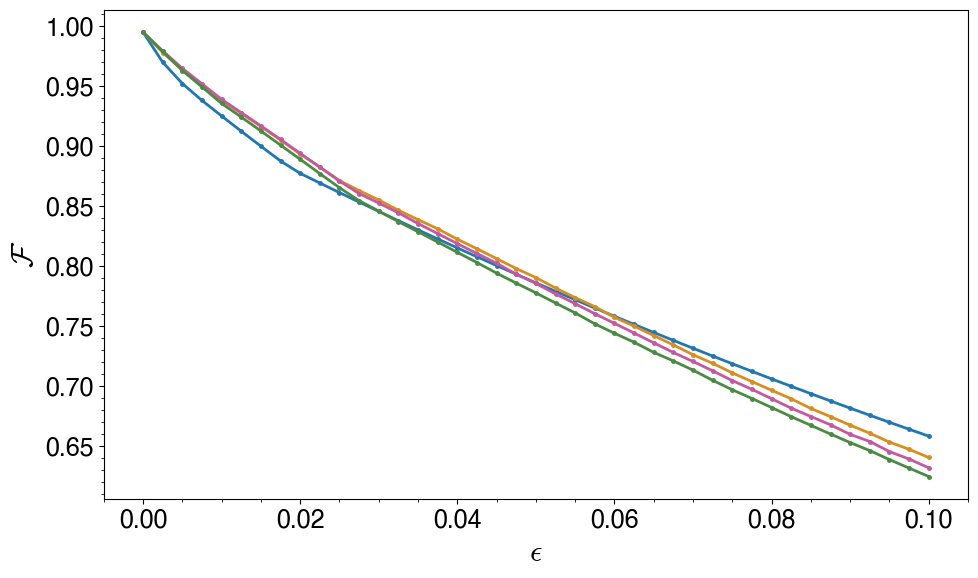

In [4]:
# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 18          # Tick labels
mpl.rcParams['ytick.labelsize'] = 18
# ==========================================================================
plt.figure(figsize=(10, 6))


custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']
# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, color= color, label=f'nqpa={nqpa}', marker='.', markersize=5, linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
plt.tight_layout()
# plt.legend()
plt.savefig('aer_trotter_estimation/big_k=2.pdf', bbox_inches='tight')

plt.show()
plt.close()

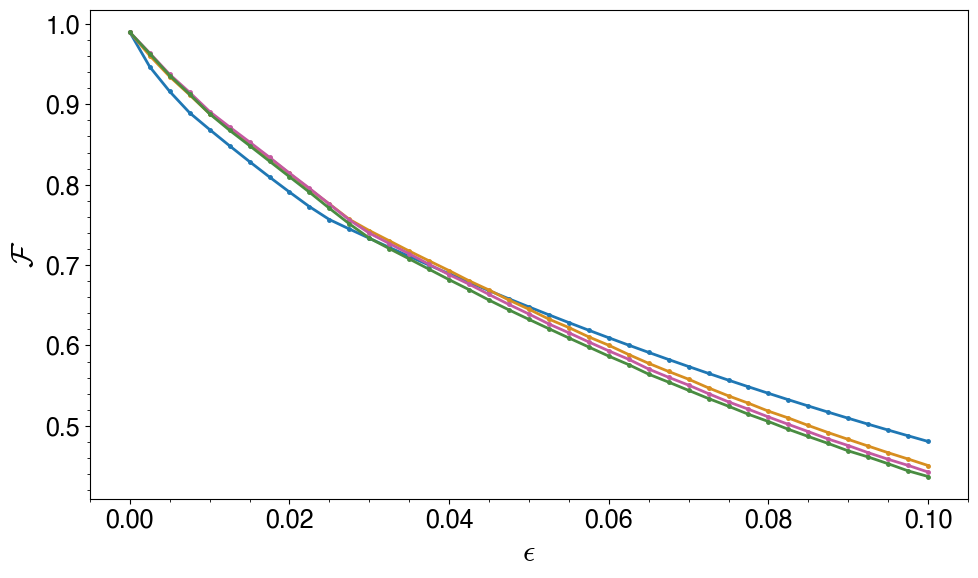

In [3]:
# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 18          # Tick labels
mpl.rcParams['ytick.labelsize'] = 18
# ==========================================================================
plt.figure(figsize=(10, 6))


custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']
# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, color= color, label=f'nqpa={nqpa}', marker='.', markersize=5, linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
plt.tight_layout()
# plt.legend()
plt.savefig('aer_trotter_estimation/big_k=3.pdf', bbox_inches='tight')

plt.show()
plt.close()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_30964/870529040.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))


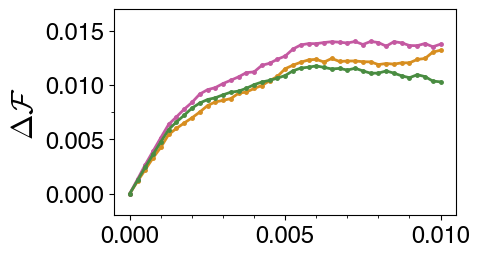

In [ ]:
plt.figure(figsize=(5, 2.8))

# Load and group files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign color
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))

# Store base for nqpa=0
base_fid_dict = {}

# Extract fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]
    fidelity_curves[nqpa] = (eps_sorted, fids_sorted)

    if nqpa == 0:
        base_fid_dict = dict(zip(eps_sorted, fids_sorted))

# Plot difference from nqpa=0
for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    if nqpa == 0:
        continue  # Skip baseline

    eps, fids = fidelity_curves[nqpa]
    base_fids = [base_fid_dict.get(e, 0) for e in eps]
    delta_fids = [f - b for f, b in zip(fids, base_fids)]

    plt.plot(eps, delta_fids, color=color, label=f'nqpa={nqpa}',  marker='.', markersize=5, linewidth=2)

# Axes tweaks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks([0.0, 0.005, 0.01])
plt.yticks([-0.03, 0, 0.005, 0.010, 0.015])
plt.ylabel(r"$\mathcal{\Delta F}$")
plt.ylim(-0.002, 0.017)
# plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('aer_trotter_estimation/insetk=2.pdf', bbox_inches='tight')
# plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_30964/4088557249.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))


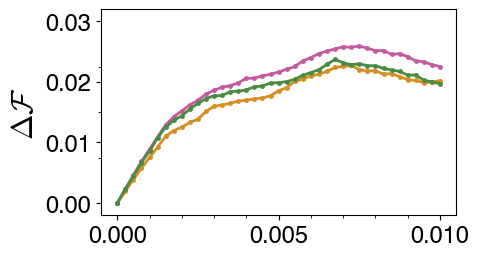

In [ ]:
plt.figure(figsize=(5, 2.8))

# Load and group files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign color
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))

# Store base for nqpa=0
base_fid_dict = {}

# Extract fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]
    fidelity_curves[nqpa] = (eps_sorted, fids_sorted)

    if nqpa == 0:
        base_fid_dict = dict(zip(eps_sorted, fids_sorted))

# Plot difference from nqpa=0
for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    if nqpa == 0:
        continue  # Skip baseline

    eps, fids = fidelity_curves[nqpa]
    base_fids = [base_fid_dict.get(e, 0) for e in eps]
    delta_fids = [f - b for f, b in zip(fids, base_fids)]

    plt.plot(eps, delta_fids, color=color, label=f'nqpa={nqpa}',  marker='.', markersize=5, linewidth=2)

# Axes tweaks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks([0.0, 0.005, 0.01])
plt.yticks([-0.03, 0.00, 0.01,0.02, 0.03])
plt.ylabel(r"$\mathcal{\Delta F}$")
plt.ylim(-0.002, 0.032)
# plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('aer_trotter_estimation/insetk=3.pdf', bbox_inches='tight')
# plt.legend()
plt.show()

## Global Depolarization

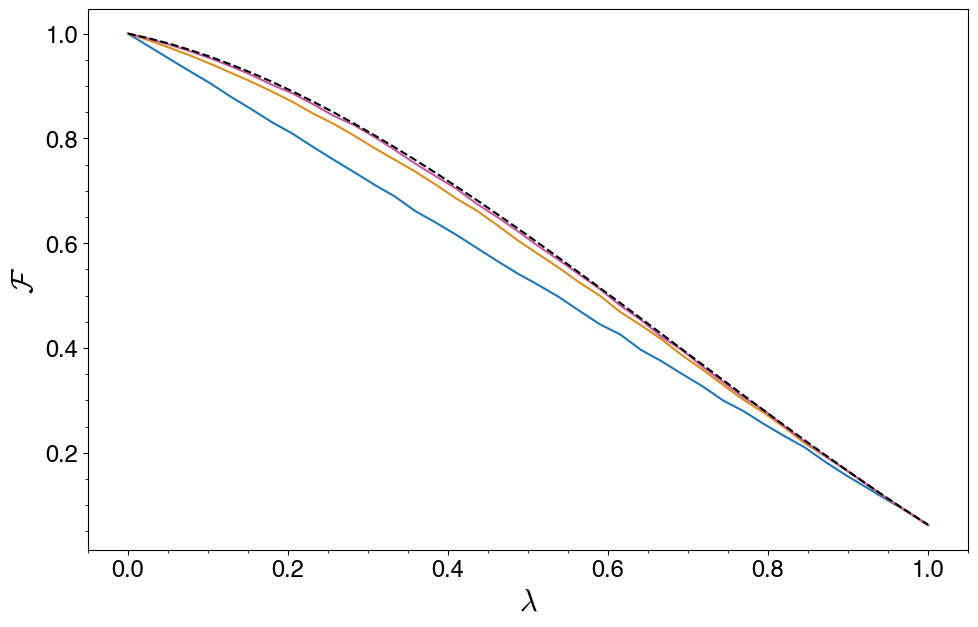

In [7]:
# Set global font settings
mpl.rcParams['font.family'] = 'Helvetica'           # Use Helvetica for main text
mpl.rcParams['mathtext.fontset'] = 'cm'             # Use Computer Modern for math (\mathcal)
mpl.rcParams['font.size'] = 14                      # Increase base font size
mpl.rcParams['axes.labelsize'] = 22                 # Axis label font size
mpl.rcParams['legend.fontsize'] = 18                # Legend font size
mpl.rcParams['xtick.labelsize'] = 17                # Tick label size
mpl.rcParams['ytick.labelsize'] = 17

## Folder containing the combined CSV files
data_folder = "aer_global_simulation/simulation_k4_shots102400_lam0.0-1.0_s41"
files = glob.glob(os.path.join(data_folder, "nqpa*_combined.csv"))

# Dict to store dataframes keyed by nqpa
data_by_nqpa = {}

# Extract nqpa and read corresponding CSV
for file in files:
    match = re.search(r'nqpa(\d+)_combined\.csv', file)
    if match:
        nqpa = int(match.group(1))
        df = pd.read_csv(file)
        data_by_nqpa[nqpa] = df
    else:
        print(f"Filename does not match expected pattern: {file}")

# Plotting
plt.figure(figsize=(10, 6.5))

label_map = {
    0: 'Unamplified',
    1: r'Amplified $N_{\mathrm{trials}}=1$',
    2: r'Amplified $N_{\mathrm{trials}}=2$'
}

for nqpa, df in sorted(data_by_nqpa.items()):
    color = custom_colors[nqpa % len(custom_colors)]
    y_key = f'QPA_{nqpa}'
    if y_key in df.columns and 'Lambda' in df.columns:
        label = label_map.get(nqpa, f'nqpa={nqpa}')
        plt.plot(df['Lambda'], df[y_key], color=color, label=label)
    else:
        print(f"Missing expected columns in nqpa={nqpa} file")

lambda_vals = df['Lambda']
theory_k4 =  (1 / 128) * (-16 + 15 * lambda_vals) * (-8 + 5 * (-1 + lambda_vals) * lambda_vals)
plt.plot(lambda_vals, theory_k4, 'k--', label='Theory')

# Add minor ticks to both axes
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\mathcal{F}$')
# plt.legend(frameon=True, edgecolor='black')
plt.tight_layout()
plt.savefig("aer_global_simulation/Simulation_k=5.pdf", format="pdf")
plt.show()

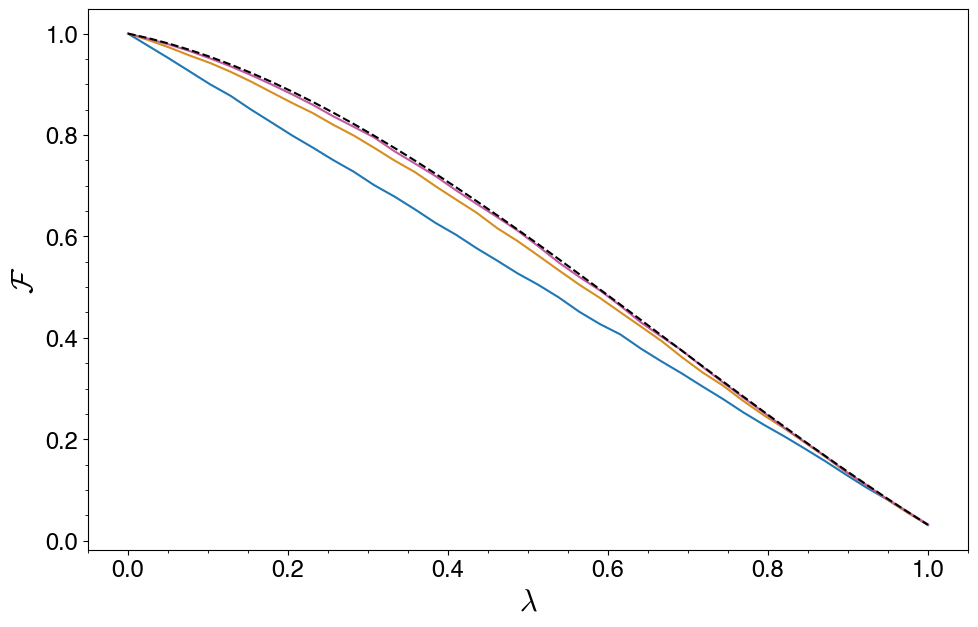

In [5]:
# Set global font settings
mpl.rcParams['font.family'] = 'Helvetica'           # Use Helvetica for main text
mpl.rcParams['mathtext.fontset'] = 'cm'             # Use Computer Modern for math (\mathcal)
mpl.rcParams['font.size'] = 14                      # Increase base font size
mpl.rcParams['axes.labelsize'] = 22                 # Axis label font size
mpl.rcParams['legend.fontsize'] = 18                # Legend font size
mpl.rcParams['xtick.labelsize'] = 17                # Tick label size
mpl.rcParams['ytick.labelsize'] = 17

## Folder containing the combined CSV files
data_folder = "aer_global_simulation/simulation_k5_shots102400_lam0.0-1.0_s41"
files = glob.glob(os.path.join(data_folder, "nqpa*_combined.csv"))

# Dict to store dataframes keyed by nqpa
data_by_nqpa = {}

# Extract nqpa and read corresponding CSV
for file in files:
    match = re.search(r'nqpa(\d+)_combined\.csv', file)
    if match:
        nqpa = int(match.group(1))
        df = pd.read_csv(file)
        data_by_nqpa[nqpa] = df
    else:
        print(f"Filename does not match expected pattern: {file}")

# Plotting
plt.figure(figsize=(10, 6.5))

label_map = {
    0: 'Unamplified',
    1: r'Amplified $N_{\mathrm{trials}}=1$',
    2: r'Amplified $N_{\mathrm{trials}}=2$'
}

for nqpa, df in sorted(data_by_nqpa.items()):
    color = custom_colors[nqpa % len(custom_colors)]
    y_key = f'QPA_{nqpa}'
    if y_key in df.columns and 'Lambda' in df.columns:
        label = label_map.get(nqpa, f'nqpa={nqpa}')
        plt.plot(df['Lambda'], df[y_key], color=color, label=label)
    else:
        print(f"Missing expected columns in nqpa={nqpa} file")

lambda_vals = df['Lambda']
theory_k5 = ((-32 + 31 * lambda_vals) * (-48 + 31 * (lambda_vals - 1) * lambda_vals)) / 1536
plt.plot(lambda_vals, theory_k5, 'k--', label='Theory')

# Add minor ticks to both axes
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\mathcal{F}$')
# plt.legend(frameon=True, edgecolor='black')
plt.tight_layout()
plt.savefig("aer_global_simulation/Simulation_k=5.pdf", format="pdf")
plt.show()